In [ ]:
import torch
from torch.utils.data import DataLoader
import os
from datasets import load_dataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import time
import threading

from transformers import AutoModelForCausalLM, AutoTokenizer, TextIteratorStreamer
from transformers import LlamaForCausalLM, LlamaTokenizerFast
import transformers

from torch import nn
from torch import optim

from torch.utils.tensorboard import SummaryWriter

from datasets import load_dataset
import pickle

tokenizer = AutoTokenizer.from_pretrained('google/gemma-7b')
gemma7 = AutoModelForCausalLM.from_pretrained('google/gemma-7b', torch_dtype=torch.float16,device_map="cuda:0")
gemma2 = AutoModelForCausalLM.from_pretrained('google/gemma-2b', torch_dtype=torch.float16,device_map="cuda:1")

/usr/local/lib/python3.10/dist-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/usr/local/lib/python3.10/dist-packages/torchvision/image.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


[2025-05-22 00:17:07,007] [INFO] [real_accelerator.py:222:get_accelerator] Setting ds_accelerator to cuda (auto detect)


/usr/bin/ld: cannot find -laio: No such file or directory
collect2: error: ld returned 1 exit status
/usr/bin/ld: cannot find -lcufile: No such file or directory
collect2: error: ld returned 1 exit status


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

## Teacher data

In [2]:
class Dataset(torch.utils.data.Dataset):
    def __init__(self, data, tokenizer):
        global paths
        global epoch
        self.data = data
        self.tokenizer = tokenizer
    def __len__(self):
        return len(self.data)

    def __getitem__(self, i):
        line=self.data[i]['text'][0:8000]
        batch  = self.tokenizer(line, max_length=1025, padding='max_length', truncation=True)
        batch  = self.tokenizer(line, max_length=1025, padding='max_length', truncation=True)
        batch['input_ids']=torch.tensor(batch['input_ids'])
        return batch


sentence = big_texts[1014]['text']
t1 = time.time()
tokenizer(sentence, max_length=1025, padding='max_length', truncation=True)
t2 = time.time()
print(t2-t1)
t1 = time.time()
tokenizer(sentence[:5000], max_length=1025, padding='max_length', truncation=True)
t2 = time.time()
print(t2-t1)
t1 = time.time()
tokenizer(sentence[:6000], max_length=1025, padding='max_length', truncation=True)
t2 = time.time()
print(t2-t1)
t1 = time.time()
tokenizer(sentence[:7000], max_length=1025, padding='max_length', truncation=True)
t2 = time.time()
print(t2-t1)
t1 = time.time()
tokenizer(sentence[:8000], max_length=1025, padding='max_length', truncation=True)
t2 = time.time()
print(t2-t1)



In [3]:
# texts = load_dataset('/media/igli/c8d7d852-a9fd-4353-be47-000a0fe82201/default-8697dcd8a26a9af6', cache_dir='~/.cache/huggingface/datasets/')['train']
# big_texts = texts.filter(lambda x : len(tokenizer(x['text'])['input_ids']) > 1025)
# big_texts.save_to_disk(".cache/huggingface/datasets/filtered-math")
# big_texts.save_to_disk('/media/igli/c8d7d852-a9fd-4353-be47-000a0fe82201/filtered-math')

In [4]:
from datasets import load_from_disk
big_texts = load_from_disk('/igli/filtered-math/')


Loading dataset from disk:   0%|          | 0/48 [00:00<?, ?it/s]

In [5]:
big_texts

Dataset({
    features: ['url', 'text', 'date', 'metadata'],
    num_rows: 2663803
})

In [6]:
# unprocessed = big_texts.select(range(14500, len(big_texts)))
unprocessed = big_texts
dataset = Dataset(unprocessed, tokenizer)

In [7]:
with torch.no_grad():
    file_no = 0 
    nbatches=500
    nfiles=500
    batch_size=2
    top_k = 100
    max_length = 1024
    model = gemma7
    
    loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=False)
    loop=tqdm(loader, leave=True)
    
    # Ground Truth IDs
    ID   = torch.zeros((nbatches*batch_size, max_length)).type(torch.int32).to(device=model.device)
    # Teacher Logits
    TL = torch.zeros((nbatches*batch_size, max_length, top_k)).type(torch.float16).to(device=model.device)
    # Teacher IDs
    T_ID   = torch.zeros((nbatches*batch_size, max_length, top_k)).type(torch.int32).to(device=model.device)

    storedid = np.fromfile('/igli/raw_logits_v2/0000_id_gt', dtype=np.int32).reshape(500, 2, 1024)
    storedtid = np.fromfile('/igli/raw_logits_v2/0000_id_t' , dtype=np.int32).reshape(500, 2, 1024, 100)
    storedtl =np.fromfile('/igli/raw_logits_v2/0000_logit_t', dtype=np.float16).reshape(500, 2, 1024, 100)
    
    for (i,batch) in enumerate(loop):
        if i > 0 and i % nbatches == 0:
            break
        i = i % nbatches
        
        labels = batch['input_ids'][..., 1:].clone().detach()
        assert (labels.cpu().numpy() == storedid[i]).all()
        input_ids      = batch['input_ids'].to(model.device)
        output=model.forward(input_ids,return_dict=True,use_cache=False,output_hidden_states=False)

        logits = output['logits'][..., :-1, :]
        sort_results = torch.topk(logits, top_k, dim=-1).indices
        assert (sort_results.cpu().numpy() == storedtid[i]).all()
        ID  [i*batch_size : (i+1)*batch_size] = labels
        T_ID[i*batch_size : (i+1)*batch_size] = sort_results
        TL  [i*batch_size : (i+1)*batch_size] = logits[torch.arange(batch_size).reshape(batch_size,1,1), torch.arange(max_length).reshape(1,max_length,1), sort_results]
        if i > 100:
            break

  0%|                                                                                                                                                          | 101/1331902 [01:05<240:19:35,  1.54it/s]


In [10]:
TL[i*batch_size : (i+1)*batch_size].shape

torch.Size([2, 1024, 100])

In [18]:
(torch.diff(TL) <= 0).all()

tensor(True, device='cuda:0')

In [20]:
(np.diff(storedtl) <= 0 ).all()

True

In [16]:
TL[:204].reshape(-1, 100).argsort()

tensor([[94, 95, 96,  ...,  4,  1,  0],
        [95, 96, 97,  ...,  2,  1,  0],
        [68, 69, 70,  ...,  2,  1,  0],
        ...,
        [97, 98, 99,  ...,  2,  1,  0],
        [99, 93, 94,  ...,  2,  1,  0],
        [96, 97, 98,  ...,  2,  1,  0]], device='cuda:0')

In [20]:
storedtl =np.fromfile('/igli/raw_logits_v2/0000_logit_t', dtype=np.float16).reshape(1000, 1024, 100)

In [24]:
storedtl[0][ind].shape

(100,)

In [27]:
logits[0, 0].shape

torch.Size([256000])

In [28]:
logits[0, ind][sort_results[0, ind]].shape

torch.Size([100])

In [32]:
for ind in range(1024):
    assert (TL[i, ind][sort_results[0, ind]].cpu().numpy() == storedtl[0][ind]).all()

In [12]:
i

0

In [11]:
storedtl[i].shape

(2, 1024, 100)

In [32]:
TL

tensor([[[119.4375, 108.4375, 107.6875,  ..., 102.7500, 102.6875, 102.6875],
         [254.8750, 254.6250, 252.0000,  ..., 245.7500, 245.7500, 245.7500],
         [ 31.0000,  30.6094,  29.0469,  ...,  22.9062,  22.9062,  22.8906],
         ...,
         [ 19.3125,  18.3281,  14.6328,  ...,   6.6602,   6.6211,   6.6172],
         [-24.3125, -26.3438, -26.6562,  ..., -30.8281, -30.8281, -30.8281],
         [ -3.4102,  -6.3984,  -9.1719,  ..., -16.3125, -16.3281, -16.3281]],

        [[119.4375, 108.4375, 107.6875,  ..., 102.7500, 102.6875, 102.6875],
         [193.8750, 190.3750, 188.3750,  ..., 180.5000, 180.5000, 180.5000],
         [ 52.8750,  48.5000,  47.1250,  ...,  37.6875,  37.6562,  37.5938],
         ...,
         [-29.9844, -37.2188, -37.4375,  ..., -43.2812, -43.2812, -43.2812],
         [-37.0625, -42.3750, -42.7812,  ..., -46.5938, -46.5938, -46.5938],
         [-39.5625, -45.2500, -46.0000,  ..., -49.7188, -49.7188, -49.7188]],

        [[119.4375, 108.4375, 107.6875,  ...

In [34]:
TL.shape

torch.Size([1000, 1024, 100])

In [36]:
storedtl.shape

(1000, 1024, 100)

In [31]:
TL[:204].cpu().numpy() == storedtl[:204]

array([[[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]],

       [[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]],

       [[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, Fal

In [14]:
torch.concatenate((torch.tensor([[1],[1]]).to(model.device), batch), dim=-1)

tensor([[     1, 203066,    578,  ..., 235248, 235274, 235324],
        [     1, 235345,  14719,  ...,    877,    614,  16140]],
       device='cuda:0')

In [22]:
TL[0].dtype

torch.float16

In [44]:
for ind in range(1024):
    assert (logits[0, ind][T_ID[0, ind]] == TL[0, ind]).all()

In [30]:
storedid = np.fromfile('/igli/raw_logits_v2/0000_id_gt', dtype=np.int32).reshape(1000, 1024)
storedtid = np.fromfile('/igli/raw_logits_v2/0000_id_t' , dtype=np.int32).reshape(1000, 1024, 100)
storedtl =np.fromfile('/igli/raw_logits_v2/0000_logit_t', dtype=np.float16).reshape(1000, 1024, 100)
storedsl = np.fromfile('/igli/raw_logits_v2/0000_3210_student_logits', dtype=np.float16).reshape(-1, 100)
storedsp = np.fromfile('/igli/raw_logits_v2/0000_3210_student_probs', dtype=np.float16).reshape(-1, 100)

In [128]:
np.fromfile('/igli/raw_logits_v2/0000_3210_student_logits', dtype=np.float32).reshape(-1, 100)

array([[-8.4304608e+07, -1.0422798e+08, -1.2310255e+08, ...,
        -7.2898848e+08, -8.1707027e+08, -3.0787245e+08],
       [-2.6015405e+06, -1.3027920e+07, -8.5059580e+06, ...,
        -2.3152859e+08, -9.4266656e+07, -2.4201454e+08],
       [-4.7445750e+06, -3.5596500e+07, -3.6645844e+07, ...,
        -4.4208909e+08, -2.0217005e+08, -5.6539968e+08],
       ...,
       [-3.3723069e+08, -3.7288714e+08, -1.2939638e+08, ...,
        -4.2918126e+09, -1.3207664e+10, -7.1407370e+09],
       [-1.4999712e+09, -9.0935309e+08, -6.6609626e+08, ...,
        -6.0734912e+08, -8.0867238e+08, -2.7220890e+08],
       [-8.6446131e+09, -1.6630486e+10, -3.7262496e+10, ...,
        -1.1462622e+10, -3.5871201e+09, -5.7649193e+09]], dtype=float32)

In [126]:
storedsp.shape == storedsl.shape

True

In [61]:
(storedid[1] == ID[1].cpu().numpy()).all()

True

In [65]:
(storedtid[:2] == T_ID[:2].cpu().numpy()).all()

True

In [40]:
(storedtl[0] == TL[0].cpu().numpy())

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]])

In [66]:
(storedtl[:2] == TL[:2].cpu().numpy()).all()

True

In [68]:
np.array([0,1,2,3,4]).argsort()

array([0, 1, 2, 3, 4])

In [74]:
np.arange(99, -1, -1)

array([99, 98, 97, 96, 95, 94, 93, 92, 91, 90, 89, 88, 87, 86, 85, 84, 83,
       82, 81, 80, 79, 78, 77, 76, 75, 74, 73, 72, 71, 70, 69, 68, 67, 66,
       65, 64, 63, 62, 61, 60, 59, 58, 57, 56, 55, 54, 53, 52, 51, 50, 49,
       48, 47, 46, 45, 44, 43, 42, 41, 40, 39, 38, 37, 36, 35, 34, 33, 32,
       31, 30, 29, 28, 27, 26, 25, 24, 23, 22, 21, 20, 19, 18, 17, 16, 15,
       14, 13, 12, 11, 10,  9,  8,  7,  6,  5,  4,  3,  2,  1,  0])

In [93]:
sort_results[0]

tensor([[     2,    185,    186,  ...,   6798,   8666, 122661],
        [235303, 235349,  27321,  ...,    604,   5536,   7435],
        [107844,    573,    926,  ...,  68512,  99131, 111212],
        ...,
        [235248,    573,   2782,  ...,   2550,   3896,  11640],
        [235274, 235284, 235324,  ..., 142607, 181044, 231886],
        [235324, 235321, 235315,  ..., 235955, 237493, 237778]],
       device='cuda:0')

In [104]:
v = torch.topk(logits[1, ind], 100).values

In [109]:
v[95]

tensor(95.6250, device='cuda:0')

In [110]:
v[96]

tensor(95.6250, device='cuda:0')

In [111]:
v[0]

tensor(102.0625, device='cuda:0')

In [107]:
v.argsort()

tensor([98, 99, 95, 96, 97, 93, 94, 90, 91, 92, 84, 85, 86, 87, 88, 89, 76, 77,
        78, 79, 80, 81, 82, 83, 73, 74, 75, 70, 71, 72, 64, 65, 66, 67, 68, 69,
        61, 62, 63, 54, 55, 56, 57, 58, 59, 60, 51, 52, 53, 48, 49, 50, 44, 45,
        46, 47, 42, 43, 39, 40, 41, 34, 35, 36, 37, 38, 33, 32, 31, 28, 29, 30,
        25, 26, 27, 24, 22, 23, 20, 21, 18, 19, 16, 17, 15, 14, 13, 12, 11, 10,
         9,  8,  7,  6,  5,  4,  3,  2,  1,  0], device='cuda:0')

ValueError: cannot reshape array of size 134750 into shape (100)

In [101]:
ind = 5
print(logits[1, ind][sort_results[1, ind]])
logits[1, ind][sort_results[1, ind]].cpu().numpy().argsort() 

tensor([102.0625, 101.2500, 100.8125, 100.5000, 100.2500, 100.0000,  99.5000,
         99.3750,  98.8125,  98.6250,  98.3750,  98.3125,  97.9375,  97.8750,
         97.8125,  97.5000,  97.3750,  97.3750,  97.3125,  97.3125,  97.2500,
         97.2500,  97.0625,  97.0625,  97.0000,  96.9375,  96.9375,  96.9375,
         96.8750,  96.8750,  96.8750,  96.7500,  96.6875,  96.6250,  96.5625,
         96.5625,  96.5625,  96.5625,  96.5625,  96.5000,  96.5000,  96.5000,
         96.4375,  96.4375,  96.3750,  96.3750,  96.3750,  96.3750,  96.3125,
         96.3125,  96.3125,  96.2500,  96.2500,  96.2500,  96.1875,  96.1875,
         96.1875,  96.1875,  96.1875,  96.1875,  96.1875,  96.1250,  96.1250,
         96.1250,  96.0625,  96.0625,  96.0625,  96.0625,  96.0625,  96.0625,
         96.0000,  96.0000,  96.0000,  95.9375,  95.9375,  95.9375,  95.8750,
         95.8750,  95.8750,  95.8750,  95.8750,  95.8750,  95.8750,  95.8750,
         95.8125,  95.8125,  95.8125,  95.8125,  95.8125,  95.81

array([99, 98, 95, 96, 97, 94, 93, 92, 90, 91, 85, 84, 86, 87, 89, 88, 82,
       83, 77, 76, 78, 79, 81, 80, 74, 75, 73, 70, 72, 71, 67, 66, 65, 64,
       69, 68, 61, 62, 63, 58, 60, 59, 54, 55, 57, 56, 51, 53, 52, 48, 50,
       49, 44, 47, 46, 45, 42, 43, 41, 40, 39, 34, 38, 35, 36, 37, 33, 32,
       31, 30, 29, 28, 27, 25, 26, 24, 22, 23, 20, 21, 19, 18, 16, 17, 15,
       14, 13, 12, 11, 10,  9,  8,  7,  6,  5,  4,  3,  2,  1,  0])

In [96]:
for ind in range(1024):
    assert (logits[1, ind][sort_results[1, ind]].cpu().numpy() == storedtl[1, ind]).all()

In [84]:
for ind in range(1024):
    assert sort_results[0, ind] == sto
    logits[0, ind][storedtid[0, ind]]

tensor([-510.0000, -518.0000, -518.5000, -520.5000, -520.5000, -521.5000,
        -521.5000, -522.0000, -522.5000, -522.5000, -523.5000, -524.0000,
        -524.0000, -525.5000, -525.5000, -526.0000, -526.0000, -526.0000,
        -526.0000, -526.5000, -526.5000, -526.5000, -526.5000, -527.0000,
        -527.0000, -527.0000, -527.0000, -527.5000, -527.5000, -527.5000,
        -527.5000, -527.5000, -527.5000, -527.5000, -528.0000, -528.0000,
        -528.0000, -528.0000, -528.0000, -528.0000, -528.0000, -528.0000,
        -528.0000, -528.0000, -528.0000, -528.0000, -528.5000, -528.5000,
        -528.5000, -528.5000, -528.5000, -528.5000, -528.5000, -528.5000,
        -528.5000, -528.5000, -528.5000, -528.5000, -528.5000, -528.5000,
        -528.5000, -528.5000, -528.5000, -528.5000, -528.5000, -528.5000,
        -529.0000, -529.0000, -529.0000, -529.0000, -529.0000, -529.0000,
        -529.0000, -529.0000, -529.0000, -529.0000, -529.0000, -529.0000,
        -529.0000, -529.0000, -529.000

In [82]:
sort_results

tensor([[[     2,    185,    186,  ...,   6798,   8666, 122661],
         [235303, 235349,  27321,  ...,    604,   5536,   7435],
         [107844,    573,    926,  ...,  68512,  99131, 111212],
         ...,
         [235248,    573,   2782,  ...,   2550,   3896,  11640],
         [235274, 235284, 235324,  ..., 142607, 181044, 231886],
         [235324, 235321, 235315,  ..., 235955, 237493, 237778]],

        [[     2,    185,    186,  ...,   6798,   8666, 122661],
         [  1915,  11981,    108,  ...,   7816,  32417,  77993],
         [ 27922, 235290,   2428,  ...,  95105, 235277, 235296],
         ...,
         [   877,   1412,    708,  ...,   4319,   7782,   5201],
         [   614,   2060,    791,  ...,   5033,   5967,   6203],
         [  2060,  22315,  16140,  ...,  20040, 192746,  51249]]],
       device='cuda:0')

In [81]:
torch.topk(logits[0], 100, -1)

torch.return_types.topk(
values=tensor([[-165.8750, -172.2500, -174.2500,  ..., -178.1250, -178.1250,
         -178.1250],
        [ 151.6250,  151.5000,  149.7500,  ...,  145.3750,  145.3750,
          145.3750],
        [-265.7500, -266.7500, -267.2500,  ..., -270.7500, -270.7500,
         -270.7500],
        ...,
        [  89.6250,   84.8750,   84.1875,  ...,   77.2500,   77.2500,
           77.2500],
        [-256.5000, -265.7500, -268.2500,  ..., -276.2500, -276.2500,
         -276.2500],
        [-510.0000, -518.0000, -518.5000,  ..., -529.0000, -529.0000,
         -529.0000]], device='cuda:0'),
indices=tensor([[     2,    185,    186,  ...,   6798,   8666, 122661],
        [235303, 235349,  27321,  ...,    604,   5536,   7435],
        [107844,    573,    926,  ...,  68512,  99131, 111212],
        ...,
        [235248,    573,   2782,  ...,   2550,   3896,  11640],
        [235274, 235284, 235324,  ..., 142607, 181044, 231886],
        [235324, 235321, 235315,  ..., 235955, 23

In [76]:
storedtl[0].argsort()

array([[99, 94, 95, ...,  2,  1,  0],
       [99, 95, 98, ...,  2,  1,  0],
       [99, 68, 69, ...,  2,  1,  0],
       ...,
       [99, 96, 98, ...,  2,  1,  0],
       [99, 90, 91, ...,  2,  1,  0],
       [99, 66, 67, ...,  2,  1,  0]])

In [75]:
storedtl[0].argsort() == np.arange(99, -1, -1)

array([[ True, False, False, ...,  True,  True,  True],
       [ True, False, False, ...,  True,  True,  True],
       [ True, False, False, ...,  True,  True,  True],
       ...,
       [ True, False, False, ...,  True,  True,  True],
       [ True, False, False, ...,  True,  True,  True],
       [ True, False, False, ...,  True,  True,  True]])

In [30]:
T_ID[0].shape

torch.Size([1024, 100])

In [35]:
TL[0]

tensor([[-165.8750, -172.2500, -174.2500,  ..., -178.1250, -178.1250,
         -178.1250],
        [ 151.6250,  151.5000,  149.7500,  ...,  145.3750,  145.3750,
          145.3750],
        [-265.7500, -266.7500, -267.2500,  ..., -270.7500, -270.7500,
         -270.7500],
        ...,
        [  89.6250,   84.8750,   84.1875,  ...,   77.2500,   77.2500,
           77.2500],
        [-256.5000, -265.7500, -268.2500,  ..., -276.2500, -276.2500,
         -276.2500],
        [-510.0000, -518.0000, -518.5000,  ..., -529.0000, -529.0000,
         -529.0000]], device='cuda:0', dtype=torch.float16)

In [33]:
sort_results

tensor([[[     2,    185,    186,  ...,   6798,   8666, 122661],
         [235303, 235349,  27321,  ...,    604,   5536,   7435],
         [107844,    573,    926,  ...,  68512,  99131, 111212],
         ...,
         [235248,    573,   2782,  ...,   2550,   3896,  11640],
         [235274, 235284, 235324,  ..., 142607, 181044, 231886],
         [235324, 235321, 235315,  ..., 235955, 237493, 237778]],

        [[     2,    185,    186,  ...,   6798,   8666, 122661],
         [  1915,  11981,    108,  ...,   7816,  32417,  77993],
         [ 27922, 235290,   2428,  ...,  95105, 235277, 235296],
         ...,
         [   877,   1412,    708,  ...,   4319,   7782,   5201],
         [   614,   2060,    791,  ...,   5033,   5967,   6203],
         [  2060,  22315,  16140,  ...,  20040, 192746,  51249]]],
       device='cuda:0')

In [32]:
(sort_results[0] == T_ID[0]).all()

tensor(True, device='cuda:0')

## Student data

In [116]:
index = np.fromfile('/igli/raw_logits_v2/0000_2167_index', dtype=np.int16).reshape(-1, 2)
sl = np.fromfile('/igli/raw_logits_v2/0000_2167_student_logits', dtype=np.float16).reshape(-1, 100)
sp = np.fromfile('/igli/raw_logits_v2/0000_2167_student_probs', dtype=np.float16).reshape(-1, 100)

In [117]:
storedid = np.fromfile('/igli/raw_logits_v2/0000_id_gt' , dtype=np.int32).reshape(-1, 1024)
storedtid = np.fromfile('/igli/raw_logits_v2/0000_id_t' , dtype=np.int32).reshape(-1, 1024, 100)
storedtl =np.fromfile('/igli/raw_logits_v2/0000_logit_t', dtype=np.float16).reshape(-1, 1024, 100)

In [138]:
((torch.softmax(torch.tensor(storedtl), dim=-1).cpu().numpy().astype('float16')) == tt / tt.sum(axis=-1, keepdims=True)).all()

False

In [133]:
tt = np.exp(storedtl - storedtl.max(axis=-1, keepdims=True))
tt / tt.sum(axis=-1, keepdims=True)

array([[[9.9512e-01, 1.6947e-03, 2.2948e-04, ..., 4.7684e-06,
         4.7684e-06, 4.7684e-06],
        [3.4814e-01, 3.0713e-01, 5.3375e-02, ..., 6.7186e-04,
         6.7186e-04, 6.7186e-04],
        [3.1567e-01, 1.1615e-01, 7.0435e-02, ..., 2.1267e-03,
         2.1267e-03, 2.1267e-03],
        ...,
        [9.5361e-01, 8.2474e-03, 4.1466e-03, ..., 4.0531e-06,
         4.0531e-06, 4.0531e-06],
        [1.0000e+00, 9.6083e-05, 7.8678e-06, ..., 0.0000e+00,
         0.0000e+00, 0.0000e+00],
        [9.9902e-01, 3.3522e-04, 2.0325e-04, ..., 0.0000e+00,
         0.0000e+00, 0.0000e+00]],

       [[9.9512e-01, 1.6947e-03, 2.2948e-04, ..., 4.7684e-06,
         4.7684e-06, 4.7684e-06],
        [7.9541e-01, 4.4891e-02, 1.8707e-02, ..., 2.9302e-04,
         2.9302e-04, 2.9302e-04],
        [5.5615e-01, 6.6467e-02, 4.0283e-02, ..., 8.3590e-04,
         8.3590e-04, 8.3590e-04],
        ...,
        [4.5239e-01, 1.0376e-01, 9.5215e-02, ..., 7.6294e-05,
         7.3910e-05, 6.8367e-05],
        [9.5

In [118]:
index

array([[  0, 278],
       [  0, 292],
       [  0, 315],
       ...,
       [999, 980],
       [999, 984],
       [999, 995]], dtype=int16)

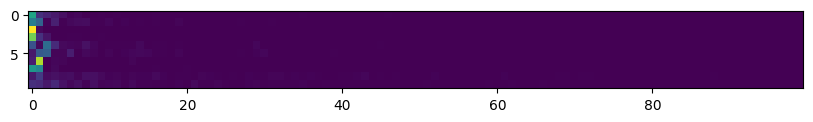

In [98]:
plt.figure(figsize=(10,10))
plt.imshow(sp[0:10,:])
# for i in range(10,20):
#     plt.plot(sp[i] )
    # plt.plot(storedtl[index[i][0]][index[i][1]]-max(storedtl[index[i][0]][index[i][1]]) )

In [119]:
gt = ((storedtid[index[:,0], index[:, 1]][..., :10] == 2167).any(axis=-1) == 0).nonzero()[0]

In [120]:
gt

array([ 219,  253,  277,  384,  444,  464,  478,  704,  708,  751,  820,
       1044, 1123, 1172, 1243, 1249, 1319, 1331, 1350, 1407, 1413, 1436,
       1635, 1653, 1660, 1701, 1773, 1881, 1892, 1974, 1991, 2054, 2090,
       2117, 2155, 2180, 2267, 2352, 2522, 2584, 2632, 2682, 2690, 2738,
       2854, 3015, 3031, 3067, 3131, 3317, 3349, 3374, 3375, 3584, 3694,
       3724, 3779, 3828, 3831, 4014, 4018, 4068, 4115, 4122, 4175, 4193,
       4249, 4288, 4305, 4357, 4396, 4487, 4539, 4674, 4765, 4771, 4826,
       4842, 4853, 4857, 4865, 4870, 4982, 5161, 5228, 5279, 5328, 5363,
       5404, 5454, 5637, 5676, 5692, 5757, 5926, 5948, 5964, 6106, 6170,
       6200, 6238, 6252, 6346, 6381, 6432, 6492])

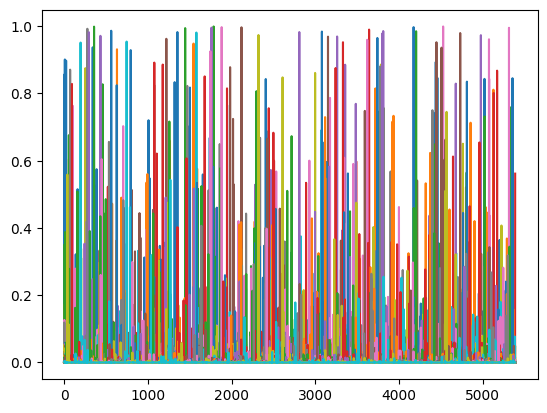

In [46]:
plt.plot(sp);

In [121]:
storedid[index[gt][:,0], index[gt][:,1]]

array([2167, 2167, 2167, 2167, 2167, 2167, 2167, 2167, 2167, 2167, 2167,
       2167, 2167, 2167, 2167, 2167, 2167, 2167, 2167, 2167, 2167, 2167,
       2167, 2167, 2167, 2167, 2167, 2167, 2167, 2167, 2167, 2167, 2167,
       2167, 2167, 2167, 2167, 2167, 2167, 2167, 2167, 2167, 2167, 2167,
       2167, 2167, 2167, 2167, 2167, 2167, 2167, 2167, 2167, 2167, 2167,
       2167, 2167, 2167, 2167, 2167, 2167, 2167, 2167, 2167, 2167, 2167,
       2167, 2167, 2167, 2167, 2167, 2167, 2167, 2167, 2167, 2167, 2167,
       2167, 2167, 2167, 2167, 2167, 2167, 2167, 2167, 2167, 2167, 2167,
       2167, 2167, 2167, 2167, 2167, 2167, 2167, 2167, 2167, 2167, 2167,
       2167, 2167, 2167, 2167, 2167, 2167, 2167], dtype=int32)

In [105]:
storedid[8,439]

1582

In [123]:
np.fromfile('/igli/raw_logits_v2/0000_id_gt' , dtype=np.int32, offset=(30*1024 + 907)*4, count=1)

array([2167], dtype=int32)

In [128]:
gt

array([ 219,  253,  277,  384,  444,  464,  478,  704,  708,  751,  820,
       1044, 1123, 1172, 1243, 1249, 1319, 1331, 1350, 1407, 1413, 1436,
       1635, 1653, 1660, 1701, 1773, 1881, 1892, 1974, 1991, 2054, 2090,
       2117, 2155, 2180, 2267, 2352, 2522, 2584, 2632, 2682, 2690, 2738,
       2854, 3015, 3031, 3067, 3131, 3317, 3349, 3374, 3375, 3584, 3694,
       3724, 3779, 3828, 3831, 4014, 4018, 4068, 4115, 4122, 4175, 4193,
       4249, 4288, 4305, 4357, 4396, 4487, 4539, 4674, 4765, 4771, 4826,
       4842, 4853, 4857, 4865, 4870, 4982, 5161, 5228, 5279, 5328, 5363,
       5404, 5454, 5637, 5676, 5692, 5757, 5926, 5948, 5964, 6106, 6170,
       6200, 6238, 6252, 6346, 6381, 6432, 6492])

In [130]:
np.arange(5)[(gt == 219).nonzero()[0][0]]

0

In [122]:
index[gt]

array([[  30,  907],
       [  34,  709],
       [  40,  944],
       [  64,  307],
       [  70,  930],
       [  71,  680],
       [  73,  106],
       [ 104,  647],
       [ 105,  110],
       [ 115,   54],
       [ 127,  325],
       [ 163,  240],
       [ 177,  886],
       [ 184,  672],
       [ 200,   75],
       [ 200,  579],
       [ 211,  191],
       [ 211,  961],
       [ 215,  337],
       [ 224,  437],
       [ 225,   33],
       [ 227,  250],
       [ 252,  174],
       [ 253,  800],
       [ 255,  173],
       [ 260,  402],
       [ 273,  411],
       [ 287,  243],
       [ 289,  188],
       [ 305,   77],
       [ 307,  683],
       [ 315,  493],
       [ 321,  588],
       [ 323,   31],
       [ 327,  978],
       [ 332,  852],
       [ 350,  244],
       [ 362,  723],
       [ 399,  328],
       [ 409,  960],
       [ 420,  430],
       [ 425, 1011],
       [ 426,  132],
       [ 434,   58],
       [ 449,  709],
       [ 473,  454],
       [ 478,  490],
       [ 480,